# Objective

From previous experimentation, it seems that this Gauss-Newton matrices while training is a bit harder to precondition than what I thought. Let's try to just extract three specific parameters at specific times while using PGD to allow me to examine the preconditioning in isolation using numpy rather than jax.numpy 

Tomorrow, we will look at different experiments and see how the conditioning works 

## First, repeat from before 

In [88]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from functools import partial
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


In [89]:
# Create standard model
class MLP_1D(nn.Module):
    num_layers: int = 2
    hidden_dim: int = 6

    @nn.compact
    def __call__(self, x):
        # Input x is expected to be of shape (batch_size, 1)
        for _ in range(self.num_layers):
            residual = x
            x = nn.Dense(
                features=self.hidden_dim, use_bias=True,
                kernel_init=nn.initializers.kaiming_uniform(),  # Kaiming uniform initialization
                bias_init=nn.initializers.zeros  # Bias initialized to zero
            )(x)
            x = nn.tanh(x) + residual  # Apply activation function after each layer
        x = nn.Dense(features=1)(x)
        return x


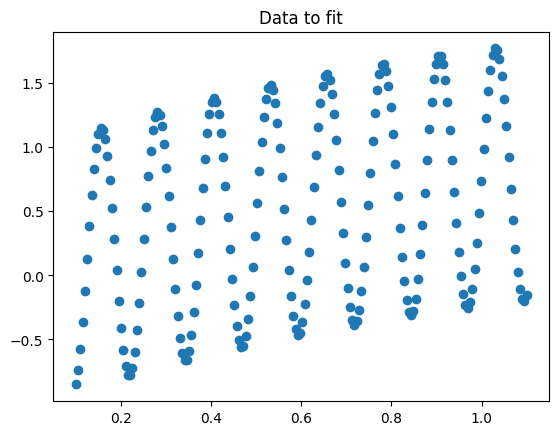

In [90]:
# Model definition 
L = 4
n = 32 

num_samples = 200
# X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
X = jnp.linspace(0, 1, num_samples).reshape((-1, 1)) + .1
y = jnp.sin(16 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)
plt.title('Data to fit')
plt.show()
# zeros_to_append = jnp.zeros((num_samples, n-1))

# # Concatenate the original array and the zeros array along axis 1 (columns)
# X = jnp.concatenate((X, zeros_to_append), axis=1)
# y = jnp.concatenate((y, zeros_to_append), axis=1)
# treescope.display((X, y))



In [91]:
@jax.jit
def tree_dot(a, b):
    return jax.tree.reduce(
        lambda x, y: x + y,
        jax.tree.map(lambda x, y: jnp.vdot(x, y), a, b)
    )

@partial(jax.jit, static_argnames=['matvec', 'preconditioner', 'tol', 'max_iter'])
def conjugate_gradient(matvec, b, state, x, tol=1e-5, max_iter=1000, preconditioner=None):
    # If no preconditioner is provided, use the identity operation
    if preconditioner is None:
        preconditioner = lambda tree: tree
    
    def body_fn(carry):
        k, r, p, rsold, i = carry
        Ap = matvec(p)
        alpha = rsold / tree_dot(p, Ap)
        k = jax.tree.map(lambda k, p: k + alpha * p, k, p)
        r = jax.tree.map(lambda r, Ap: r - alpha * Ap, r, Ap)

        
        # Apply the preconditioner to the new residual
        z = preconditioner(r)
        rsnew = tree_dot(r, z) # Now it's r^T z instead of r^T r
        
        beta = rsnew / rsold
        p = jax.tree.map(lambda z_val, p_val: z_val + beta * p_val, z, p) # Update p using z
        return k, r, p, rsnew, i + 1

    def cond_fn(carry):
        _, _, _, rsnew, i = carry
        return jnp.logical_and(jnp.sqrt(rsnew) >= tol, i < max_iter)

    # k = jax.tree.map(jnp.zeros_like, b)  # Initial guess k = 0
    k = b
    r = jax.tree.map(lambda x: x, b)  # Initial residual r = b - A * k (A * k = 0 initially)
    p = jax.tree.map(lambda x: x, r)  # Initial direction p = r
    rsold = tree_dot(r, r)

    init_carry = (k, r, p, rsold, 0)
    k, r, p, rsnew, i = jax.lax.while_loop(cond_fn, body_fn, init_carry)

    return k, (jnp.sqrt(rsnew), i)


In [92]:
def train_model_precond_cg(X_train, y_train, model, params, learning_rate, num_epochs,
                          lamb=5e-2):
    print('Not intended for real training runs! Only to extract params ')
    specific_epochs = [0, 2500, 4500]
    
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)
    
    @jax.jit
    def train_step(state, batch_X, batch_y):
        """
        We use full batch
        """
        @jax.jit
        def loss_fn(params):
            predictions = state.apply_fn({'params': params}, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn(state.params)

        # Conjugate gradient
        # TODO: figure out why 
        # _, f_jvp = jax.linearize(lambda p: 
                                 # state.apply_fn({'params': params}, batch_X), state.params)
        # worked so well? 
        _, f_jvp = jax.linearize(lambda p: 
                                 state.apply_fn({'params': p}, batch_X), 
                                 state.params)
        f_vjp = jax.linear_transpose(f_jvp, state.params)
        
        @jax.jit
        def matvec(k):
            Av = f_vjp(f_jvp(k))[0]
            # Add the regularization term lambda * k
            Av = jax.tree_util.tree_map(lambda a, b: a + lamb * b, Av, k)
            return Av

        grads_cg, lm_data = conjugate_gradient(
            matvec, grads, state, batch_X, max_iter=1000,tol=1e-6
        )

        # We can verify that they're equal by explicitly constructing matrices 
        # Explicitly construct Jacobian 
        # jacobian = jax.jacobian(state.apply_fn, argnums=0)({'params': params}, X)
        # flattened, _ = jax.tree.flatten(jacobian)
        # reshaped_leaves = [leaf.reshape(batch_X.shape[0], -1) for leaf in flattened]
        # aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        # jacobian = aggregated_array.reshape((batch_X.shape[0], -1))
        # jtj = jacobian.T @ jacobian

        # lm_mat = lamb * jnp.eye(jtj.shape[0]) + jtj
        # flattened, back = jax.flatten_util.ravel_pytree(grads)
        # altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
        # grads_mat = back(altered) # Convert vector back to PyTree
        
        # l2_norm_diff = jnp.sqrt(sum(jnp.sum((a - b)**2) for a, b in zip(jax.tree_leaves(grads_cg), jax.tree_leaves(grads_mat))))
        # l2_norm_grads_mat = jnp.sqrt(sum(jnp.sum(b**2) for b in jax.tree_leaves(grads_mat)))
        # relative_error = l2_norm_diff / l2_norm_grads_mat
        # jax.debug.print("Diff {relative_error}", relative_error=relative_error)

        # jax.debug.print('Mat {altered}', altered=altered)
        # cg_vec, _ = jax.flatten_util.ravel_pytree(grads_cg)
        # jax.debug.print('cg {altered}', altered=cg_vec)
        # jax.debug.print('cg iter {altered}', altered= lm_data[1])
        
        state = state.apply_gradients(grads=grads_cg)
        return state, loss, lm_data

    losses = []
    cg_stats = {
        'resids': [], 'iters': [],
        'params': []
    }

    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss, lm_data = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)
        cg_stats['resids'].append(lm_data[0])
        cg_stats['iters'].append(lm_data[1])

        if epoch in specific_epochs:
            cg_stats['params'].append(
                state.params
            )
            
            

    return state, losses, cg_stats

num_epochs = 5_000

key = jax.random.PRNGKey(0)

model = MLP_1D(num_layers=L, hidden_dim=n)
params = model.init(key, jnp.ones((1, 1)))['params']

# Train the model
trained_state_precond_cg, precond_losses_cg, cg_stats = train_model_precond_cg(
    X, y, model, params, learning_rate=2e-2, num_epochs=num_epochs, lamb=1e-2
)

Not intended for real training runs! Only to extract params 
Starting training for 5000 epochs...


  0%|          | 0/5000 [00:00<?, ?it/s]

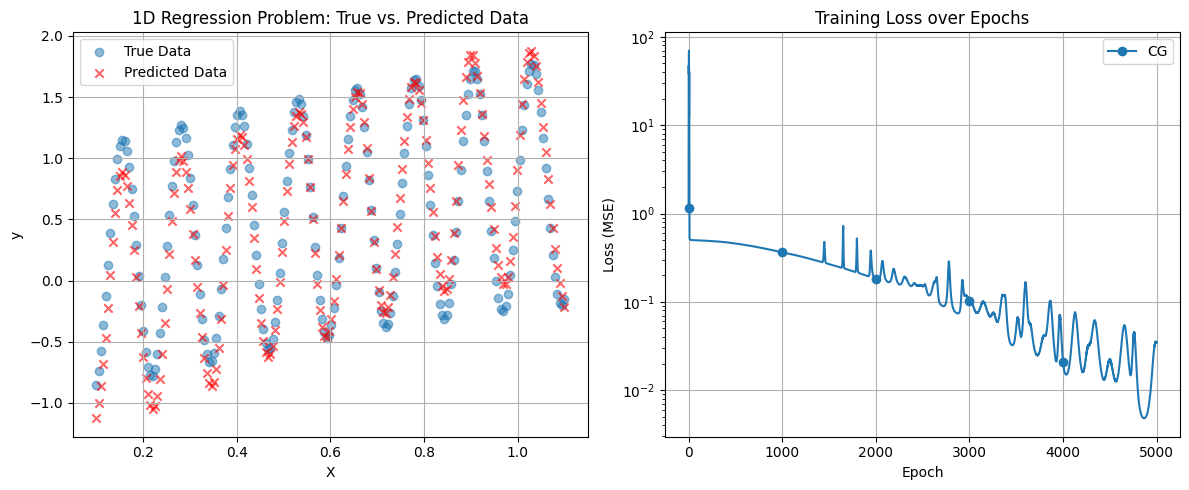

In [93]:
predicted_y = model.apply({'params': trained_state_precond_cg.params}, X)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# First subplot for True vs. Predicted Data
plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
plt.title('1D Regression Problem: True vs. Predicted Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Second subplot for Training Loss over Epochs
plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
# plt.semilogy(precond_losses, 'x-', label='Precond', markevery=500)
# plt.semilogy(sgd_losses, label='SGD')
plt.semilogy(precond_losses_cg, 'o-', label='CG', markevery=1000)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Show the combined plot
plt.tight_layout()  
plt.show()

## With weights saved; we need helper functions to construct the matrices

In [94]:
def make_matrix(params):
    jacobian = jax.jacobian(model.apply, argnums=0)({'params': params}, X)
    flattened, _ = jax.tree.flatten(jacobian)
    reshaped_leaves = [leaf.reshape(X.shape[0], -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    jacobian = aggregated_array.reshape((X.shape[0], -1))
    jtj = jacobian.T @ jacobian
    
    lm_mat = 1e-2 * jnp.eye(jtj.shape[0]) + jtj
    return lm_mat 

specific_epochs = [0, 2500, 4500]

In [95]:
for i, param in enumerate(cg_stats['params']):
    eigs = jnp.sort(jnp.linalg.eigvalsh(make_matrix(param)))
    print(f'{specific_epochs[i]}\t Condition number {jnp.max(eigs) / jnp.min(eigs):.2e} Iterations {cg_stats['iters'][specific_epochs[i]]}')

0	 Condition number 2.56e+06 Iterations 45
2500	 Condition number 1.10e+06 Iterations 439
4500	 Condition number 1.11e+06 Iterations 525


It's interesting that the later ones have smaller condition number but much higher iteration counts. 

## Verify that diagonal scaling doesn't work

In [96]:
for i, param in enumerate(cg_stats['params']):
    mat = make_matrix(param)
    precond = jnp.diag(1 / jnp.sqrt(jnp.diag(mat))) # Not efficient but it's okay
    mat = precond @ mat @ precond
    
    eigs = jnp.sort(jnp.linalg.eigvalsh(mat))
    print(f'{specific_epochs[i]}\t Condition number {jnp.max(eigs) / jnp.min(eigs):.2e} Iterations {cg_stats['iters'][specific_epochs[i]]}')

0	 Condition number 2.87e+08 Iterations 45
2500	 Condition number 5.60e+07 Iterations 439
4500	 Condition number 5.90e+07 Iterations 525


## Check block diagonal 

In [97]:
param_list = []
for name, layer_params in params.items(): 
    param_list.append(sum(param.size for param in layer_params.values()))
assert sum(param.size for param in jax.tree_util.tree_leaves(params)) == sum(param_list)
param_list

[64, 1056, 1056, 1056, 33]

In [98]:
def matrix_inverse_square_root_spd(A):
    eigenvalues, eigenvectors = jnp.linalg.eigh(A)
    eigenvalues = jnp.where(eigenvalues < 1e-12, 1e-12, eigenvalues)
    inverse_sqrt_eigenvalues = jnp.diag(1.0 / jnp.sqrt(eigenvalues))
    A_inv_half = eigenvectors @ inverse_sqrt_eigenvalues @ eigenvectors.T
    return A_inv_half

0	 Condition number 3.02e+06 Iterations 45
2500	 Condition number 1.24e+06 Iterations 439
4500	 Condition number 1.10e+06 Iterations 525


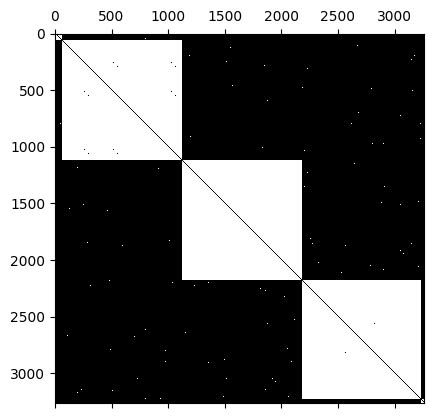

In [118]:
for i, param in enumerate(cg_stats['params']):
    mat = make_matrix(param)

    block_diag = jnp.zeros_like(mat)

    index = 0
    blocks = []
    for block_size in param_list:
        block = matrix_inverse_square_root_spd(
            mat[index:index + block_size, index:index + block_size]
        )
        
        blocks.append(
            block
        )
        index += block_size

    precond = jax.scipy.linalg.block_diag(*blocks).astype('float32')
    # treescope.display(precond[0:80, 0:80])
    mat = precond @ mat @ precond.T
    # print(mat.shape)
    temp_mat = jnp.where(jnp.abs(mat) > 1e-6, mat, 0)
    plt.spy(temp_mat)
    # plt.show()
    # treescope.display(mat[0:120, 0:120])
    # break

    eigs = jnp.sort(jnp.linalg.eigvalsh(mat))
    print(f'{specific_epochs[i]}\t Condition number {jnp.max(eigs) / jnp.min(eigs):.2e} Iterations {cg_stats['iters'][specific_epochs[i]]}')

## TODO: Try block tri diagonal? There's only a few layers so hmmm

## Try using the full Hessian? Maybe good for using BFGS 

Oh god; this takes up too much memory apparently; whelp this doesn't work.... 


In [ ]:
# Need a loss function to grab gradients and such 
@jax.jit
def loss_fn(params):
    predictions = model.apply({'params': params}, X)
    loss = jnp.mean(jnp.square(predictions - y))
    return loss, predictions

# def hessian():
#   return jax.jit(jax.jacfwd(jax.jacrev(loss_fn)))

# hessian()(params)
# jax.jacrev(loss_fn)(params)
jax.hessian(loss_fn)(params)

## Try the layer structure? 

This becomes a question of how to construct it well; we need to type this up using Kronecker products or else it becomes unfeasible. I need to retype my notes using the correct notation and actually be smart about construction!!! 

TODO. 

## Try low rank thing? 

This is kind of silly, but if batch size is of 1, then inverting the Gauss-Newton matrix is trivial, as it's simply, by SMW formula
$$(\lambda I + v^Tv)^{-1} = \frac{1}{\lambda}I - \frac{v^Tv}{\lambda^2 (1 + 1/\lambda v v^T)}$$
This is realy easy to calculate. Thus, perhaps we can do something silly like sum these together? 

Okay, below shows that this is not trivial... doing this calculation is fine, but the inverse is hard. It doesn't seem to do much...



In [197]:
def matrix_square_root_spd(A):
    eigenvalues, eigenvectors = jnp.linalg.eigh(A)
    eigenvalues = jnp.where(eigenvalues < 1e-12, 1e-12, eigenvalues)
    inverse_sqrt_eigenvalues = jnp.diag(jnp.sqrt(eigenvalues))
    A_inv_half = eigenvectors @ inverse_sqrt_eigenvalues @ eigenvectors.T
    return A_inv_half

In [204]:
def make_single_rank_approx(params):
    jacobian = jax.jacobian(model.apply, argnums=0)({'params': params}, X)
    flattened, _ = jax.tree.flatten(jacobian)
    reshaped_leaves = [leaf.reshape(X.shape[0], -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    jacobian = aggregated_array.reshape((X.shape[0], -1))

    approx_inverse = jnp.eye(jacobian.shape[1]) / 1e-2 * X.shape[0]
    for i in range(X.shape[0]):
        v = jacobian[i, :].reshape((1, -1))
        # print(( v.T @ v ).shape)
        # Try with some scaled? 5e-3 scaling works? 
        approx_inverse = approx_inverse - v.T @ v / (1e-2 ** 2 * (1 + 1 / 1e-2 * v @ v.T))

    return approx_inverse 



In [205]:
test_inv = make_single_rank_approx(cg_stats['params'][0])
treescope.display(jnp.linalg.eigvalsh(test_inv))
test_inv = make_matrix(cg_stats['params'][0])
(jnp.linalg.eigvalsh(jnp.linalg.inv(test_inv)))

<jax.Array float64(3265,) ≈1e+02 ±5.1 [≥4.4e-05, ≤1.1e+02] nonzero:3_265
  <Arrayviz rendering>
| Device: GPU 0>

0	 Condition number 4.49e+05 Iterations 45
2500	 Condition number 8.57e+05 Iterations 439
4500	 Condition number 9.25e+05 Iterations 525


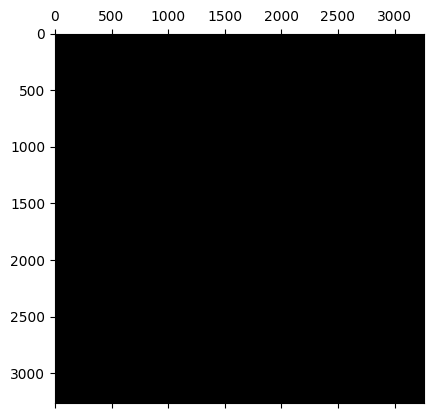

In [206]:
for i, param in enumerate(cg_stats['params']):
    mat = make_matrix(param)

    # precond = jnp.zeros_like(mat)
    test_inv = make_single_rank_approx(cg_stats['params'][i])
    precond = matrix_square_root_spd(test_inv)
    
    mat = precond @ mat @ precond.T
    # print(mat.shape)
    temp_mat = jnp.where(jnp.abs(mat) > 1e-6, mat, 0)
    plt.spy(temp_mat)

    eigs = jnp.sort(jnp.linalg.eigvalsh(mat))
    print(f'{specific_epochs[i]}\t Condition number {jnp.max(eigs) / jnp.min(eigs):.2e} Iterations {cg_stats['iters'][specific_epochs[i]]}')

## Try using an approximation of SMW as a preconditioner? 

So basically, we know that the 

In [213]:
def make_smw_approx(params):
    jacobian = jax.jacobian(model.apply, argnums=0)({'params': params}, X)
    flattened, _ = jax.tree.flatten(jacobian)
    reshaped_leaves = [leaf.reshape(X.shape[0], -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    jacobian = aggregated_array.reshape((X.shape[0], -1))

    return 1 / 1e-2 * jnp.eye(jacobian.shape[1]) -  1 / (1e-2)**2 * jacobian.T @ jacobian



0	 Condition number 4.11e+13 Iterations 45
2500	 Condition number 4.34e+13 Iterations 439
4500	 Condition number 4.72e+13 Iterations 525


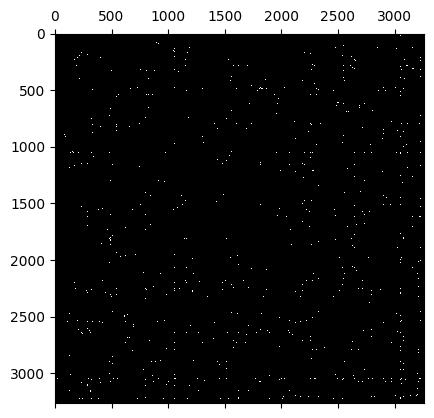

In [214]:
for i, param in enumerate(cg_stats['params']):
    mat = make_matrix(param)

    # precond = jnp.zeros_like(mat)
    test_inv = make_smw_approx(param)
    precond = matrix_square_root_spd(test_inv)
    
    mat = precond @ mat @ precond
    # print(mat.shape)
    temp_mat = jnp.where(jnp.abs(mat) > 1e-6, mat, 0)
    plt.spy(temp_mat)

    eigs = jnp.sort(jnp.linalg.eigvalsh(mat))
    print(f'{specific_epochs[i]}\t Condition number {jnp.max(eigs) / jnp.min(eigs):.2e} Iterations {cg_stats['iters'][specific_epochs[i]]}')

## Use BFGS type thing? Create preconditioner on the fly??? 

How does BFGS do an approximation of the Hessian???